In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data1 = pd.read_excel("Fact_Properties.xlsx")
data2 = pd.read_excel("Dim_PropertyDetails.xlsx")
data3 = pd.read_excel("Dim_Location.xlsx")

In [ ]:
D1=data1.copy()
D2=data2.copy()
D3=data3.copy()

In [ ]:
D2.isnull().sum()




,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,62
Landsize,0
BuildingArea,5001
YearBuilt,4078


In [ ]:
D2["Car"].isnull().mean()*100


np.float64(0.5201778672707441)

In [ ]:
D2["Car"].fillna(D2["Car"].mean(),inplace=True)

/tmp/ipykernel_8159/714677238.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  D2["Car"].fillna(D2["Car"].mean(),inplace=True)


In [ ]:
D2.isnull().sum()


,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,5001
YearBuilt,4078


In [ ]:
q1=D2['Car'].quantile(0.25)
q3=D2['Car'].quantile(0.75)
iqr=q3-q1
upper_limit=q3+(1.5*iqr)
lower_limit=q1-(1.5*iqr)
outliers=D2[(D2['Car']>upper_limit) | (D2['Car']<lower_limit)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(D2)*100)

5.252118466314288


In [ ]:
D2['Car']=D2['Car'].clip(lower_limit,upper_limit)

In [ ]:
q1=D2['Car'].quantile(0.25)
q3=D2['Car'].quantile(0.75)
iqr=q3-q1
upper1_limit=q3+(1.5*iqr)
lower1_limit=q1-(1.5*iqr)
outliers=D2[(D2['Car']>upper1_limit) | (D2['Car']<lower1_limit)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(D2)*100)

0.0


In [ ]:
D2["BuildingArea"].isnull().mean()*100

np.float64(41.95821797130632)

In [ ]:
q1=D2['BuildingArea'].quantile(0.25)
q3=D2['BuildingArea'].quantile(0.75)
iqr=q3-q1
upperr_limit=q3+(1.5*iqr)
lowerr_limit=q1-(1.5*iqr)
outliers=D2[(D2['BuildingArea']>upperr_limit) | (D2['Car']<lowerr_limit)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(D2)*100)

2.9364879603993623


<Axes: ylabel='BuildingArea'>

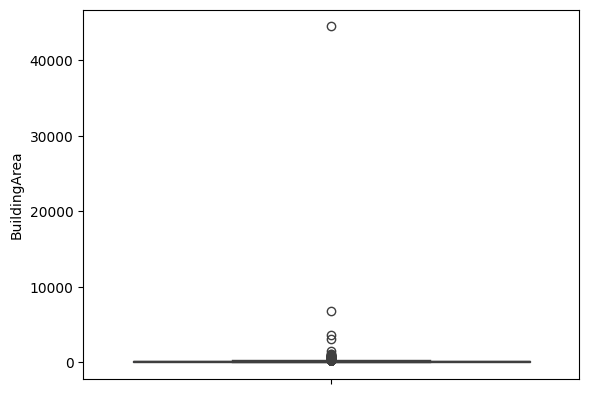

In [ ]:
sns.boxplot(D2['BuildingArea'])

<Axes: xlabel='BuildingArea', ylabel='Count'>

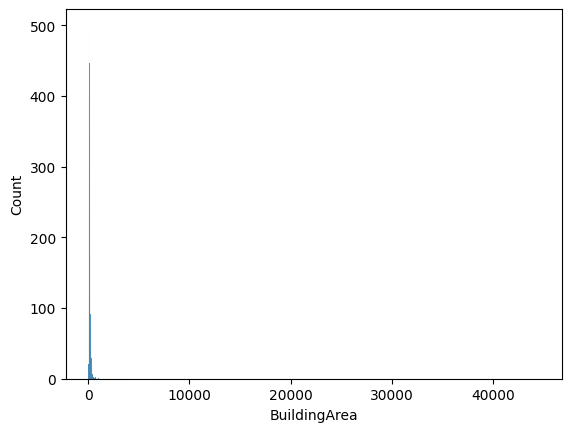

In [ ]:
sns.histplot(D2['BuildingArea'])

In [ ]:
D2['BuildingArea']=D2['BuildingArea'].clip(lowerr_limit,upperr_limit)

In [ ]:
q1=D2['BuildingArea'].quantile(0.25)
q3=D2['BuildingArea'].quantile(0.75)
iqr=q3-q1
upperr_limit=q3+(1.5*iqr)
lowerr_limit=q1-(1.5*iqr)
outliers=D2[(D2['BuildingArea']>upperr_limit) | (D2['Car']<lowerr_limit)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(D2)*100)

0.0


<Axes: xlabel='BuildingArea', ylabel='Count'>

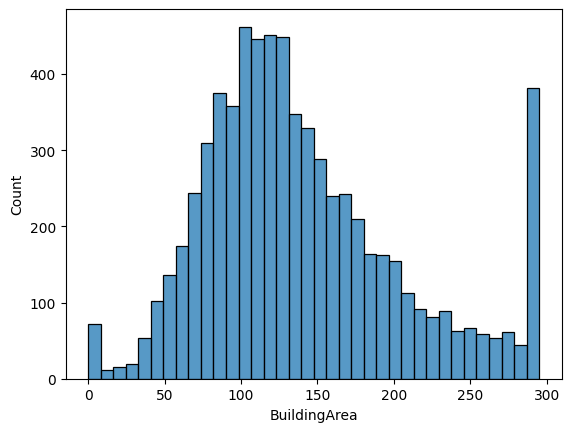

In [ ]:
sns.histplot(D2['BuildingArea'])

<Axes: ylabel='BuildingArea'>

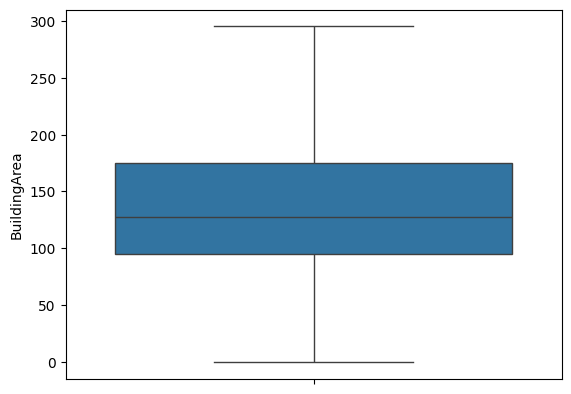

In [ ]:
sns.boxplot(D2['BuildingArea'])

In [ ]:
D2.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,5001
YearBuilt,4078


<Axes: ylabel='BuildingArea'>

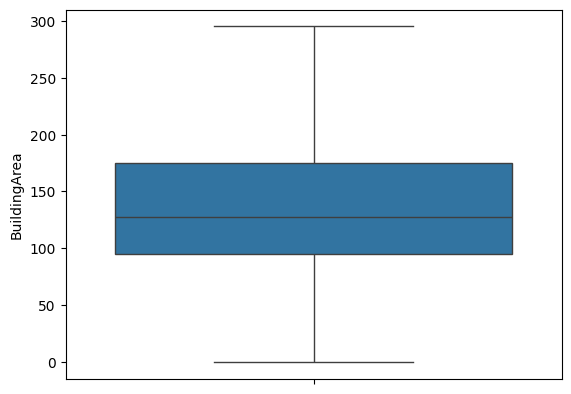

In [ ]:
sns.boxplot(D2['BuildingArea'])

<Axes: xlabel='BuildingArea', ylabel='Count'>

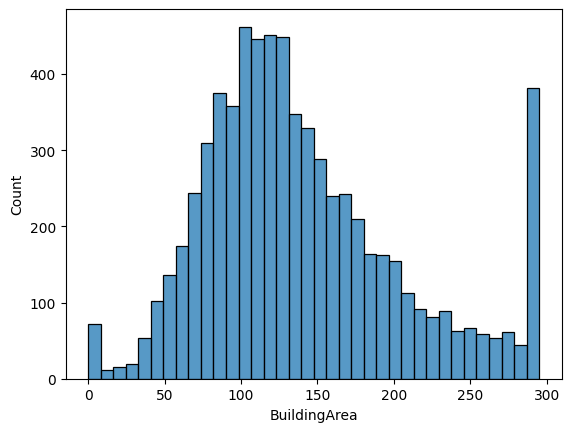

In [ ]:
sns.histplot(D2['BuildingArea'])

In [ ]:
D2["BuildingArea"].isnull().mean()*100

np.float64(41.95821797130632)

In [ ]:
merged1 = pd.merge(D2, D1, on='PropertyDetailsID', how='left')

In [ ]:
D1.head()

,PropertyID,Address,Price,Method,SellerG,Date,LocationID,PropertyDetailsID
0,1,85 Turner St,1480000,S,Biggin,2016-12-03,1,543
1,2,25 Bloomburg St,1035000,S,Biggin,2016-02-04,1,183
2,3,5 Charles St,1465000,SP,Biggin,2017-03-04,1,3904
3,4,40 Federation La,850000,PI,Biggin,2017-03-04,1,4003
4,5,55a Park St,1600000,VB,Nelson,2016-06-04,1,5663


In [ ]:
D2.head()

,PropertyDetailsID,Type,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
0,1,h,1,1,1,0.0,67,72.0,1900.0
1,2,h,1,1,1,0.0,74,NaN,1900.0
2,3,h,1,1,1,0.0,81,54.0,1900.0
3,4,h,1,1,1,0.0,84,NaN,1912.0
4,5,h,1,1,1,0.0,85,NaN,NaN


In [ ]:
merged1.head()

,PropertyDetailsID,Type,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,PropertyID,Address,Price,Method,SellerG,Date,LocationID
0,1,h,1,1,1,0.0,67,72.0,1900.0,12844,250 Ferrars St,855000,S,Greg,2017-09-16,613
1,2,h,1,1,1,0.0,74,NaN,1900.0,10507,67 Dow St,807500,S,Greg,2017-05-27,612
2,3,h,1,1,1,0.0,81,54.0,1900.0,120,9 Durham St,985000,S,Marshall,2016-07-30,14
3,4,h,1,1,1,0.0,84,NaN,1912.0,5530,218 Ferrars St,1002000,S,Marshall,2016-12-03,614
4,5,h,1,1,1,0.0,85,NaN,NaN,9688,58 Station St,964000,S,Cayzer,2017-06-17,559


In [ ]:
merged1.shape


(13580, 16)

In [ ]:
merged1.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,6450
YearBuilt,5375
PropertyID,0


In [ ]:
merged2=pd.merge(merged1,D3,on='LocationID',how='left')

In [ ]:
merged2.head()

,PropertyDetailsID,Type,Rooms,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,PropertyID,...,Date,LocationID,Suburb,Postcode,Distance,Regionname,CouncilArea,AvgLatitude,AvgLongitude,Propertycount
0,1,h,1,1,1,0.0,67,72.0,1900.0,12844,...,2017-09-16,613,South Melbourne,3205,1.9,Southern Metropolitan,NaN,-37.835328,144.958069,5943
1,2,h,1,1,1,0.0,74,NaN,1900.0,10507,...,2017-05-27,612,South Melbourne,3205,1.9,Southern Metropolitan,Port Phillip,-37.835194,144.960302,5943
2,3,h,1,1,1,0.0,81,54.0,1900.0,120,...,2016-07-30,14,Albert Park,3206,3.3,Southern Metropolitan,Port Phillip,-37.844015,144.953104,3280
3,4,h,1,1,1,0.0,84,NaN,1912.0,5530,...,2016-12-03,614,South Melbourne,3205,2.1,Southern Metropolitan,Port Phillip,-37.835306,144.961300,5943
4,5,h,1,1,1,0.0,85,NaN,NaN,9688,...,2017-06-17,559,Port Melbourne,3207,3.5,Southern Metropolitan,Port Phillip,-37.838642,144.939697,8648


In [ ]:
merged2.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,6450
YearBuilt,5375
PropertyID,0


In [ ]:
merged2['BuildingArea']=merged2.groupby(["Suburb","Price"])["BuildingArea"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['BuildingArea'].isnull().sum()

NameError: name 'merged2' is not defined

In [ ]:
merged2['BuildingArea']=merged2.groupby(["Regionname","Price"])["BuildingArea"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['BuildingArea'].isnull().sum()

np.int64(1664)

In [ ]:
merged2['BuildingArea']=merged2.groupby(["Regionname","Suburb"])["BuildingArea"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['BuildingArea'].isnull().sum()

np.int64(6)

In [ ]:
merged2['BuildingArea']=merged2.groupby(["Rooms","Price"])["BuildingArea"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['BuildingArea'].isnull().sum()

np.int64(2)

In [ ]:
merged2['BuildingArea']=merged2.groupby(["Type","Price"])["BuildingArea"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['BuildingArea'].isnull().sum()

np.int64(1)

In [ ]:
merged2['BuildingArea'].fillna(merged2['BuildingArea'].mean(),inplace=True)

/tmp/ipykernel_8159/4289507634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged2['BuildingArea'].fillna(merged2['BuildingArea'].mean(),inplace=True)


In [ ]:
merged2['BuildingArea'].isnull().sum()

np.int64(0)

<Axes: ylabel='BuildingArea'>

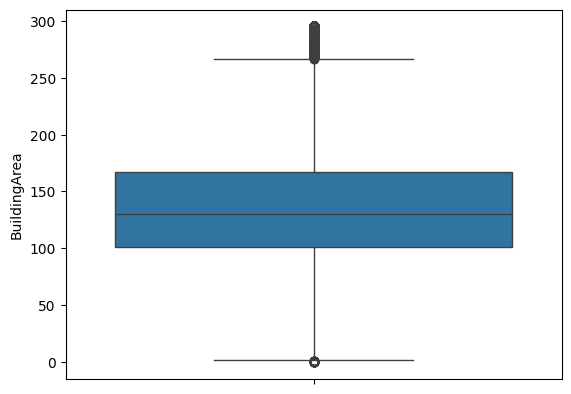

In [ ]:
sns.boxplot(merged2['BuildingArea'])

In [ ]:
q1=merged2['BuildingArea'].quantile(0.25)
q3=merged2['BuildingArea'].quantile(0.75)
iqr=q3-q1
upper_limit4=q3+(1.5*iqr)
lower_limit4=q1-(1.5*iqr)
outliers=merged2[(merged2['BuildingArea']>upper_limit4) | (merged2['BuildingArea']<lower_limit4)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(merged2)*100)

4.948453608247423


In [ ]:
merged2['BuildingArea']=merged2['BuildingArea'].clip(lower_limit4,upper_limit4)

In [ ]:
q1=merged2['BuildingArea'].quantile(0.25)
q3=merged2['BuildingArea'].quantile(0.75)
iqr=q3-q1
upper_limit44=q3+(1.5*iqr)
lower_limit44=q1-(1.5*iqr)
outliers=merged2[(merged2['BuildingArea']>upper_limit44) | (merged2['BuildingArea']<lower_limit44)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(merged2)*100)

0.0


<Axes: ylabel='BuildingArea'>

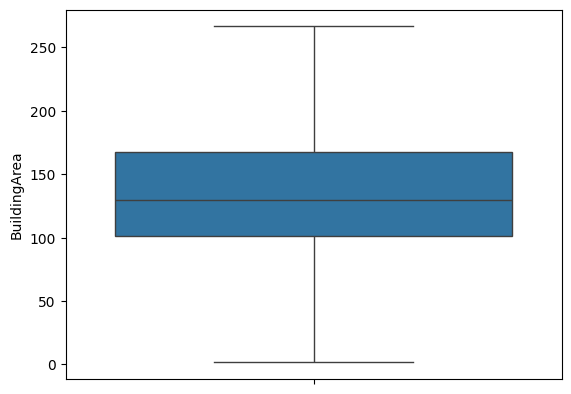

In [ ]:
sns.boxplot(merged2['BuildingArea'])

<Axes: xlabel='BuildingArea', ylabel='Count'>

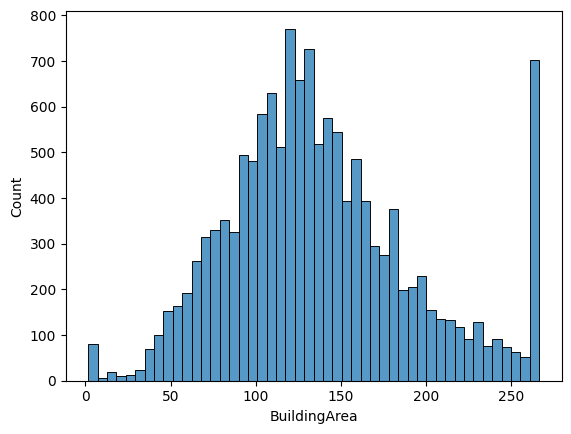

In [ ]:
sns.histplot(merged2['BuildingArea'])

In [ ]:
merged2.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,0
YearBuilt,5375
PropertyID,0


In [ ]:
merged2['YearBuilt'].isnull().sum()

np.int64(5375)

In [ ]:
merged2['YearBuilt']=merged2.groupby(["Type","Suburb"])["YearBuilt"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['YearBuilt'].isnull().sum()

np.int64(80)

In [ ]:
merged2['YearBuilt']=merged2.groupby(["Type","Regionname"])["YearBuilt"].transform(
    lambda x: x.fillna(x.mean()))

In [ ]:
merged2['YearBuilt'].isnull().sum()

np.int64(0)

In [ ]:
q1=merged2['YearBuilt'].quantile(0.25)
q3=merged2['YearBuilt'].quantile(0.75)
iqr=q3-q1
upper_limit5=q3+(1.5*iqr)
lower_limit5=q1-(1.5*iqr)
outliers=merged2[(merged2['YearBuilt']>upper_limit5) | (merged2['YearBuilt']<lower_limit5)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(merged2)*100)

0.9057437407952873


In [ ]:
merged2['YearBuilt']=merged2['YearBuilt'].clip(lower_limit5,upper_limit5)

In [ ]:
q1=merged2['YearBuilt'].quantile(0.25)
q3=merged2['YearBuilt'].quantile(0.75)
iqr=q3-q1
upper_limit55=q3+(1.5*iqr)
lower_limit55=q1-(1.5*iqr)
outliers=merged2[(merged2['YearBuilt']>upper_limit55) | (merged2['YearBuilt']<lower_limit55)]
number_of_outliers=len(outliers)
print(number_of_outliers/len(merged2)*100)

0.0


<Axes: ylabel='YearBuilt'>

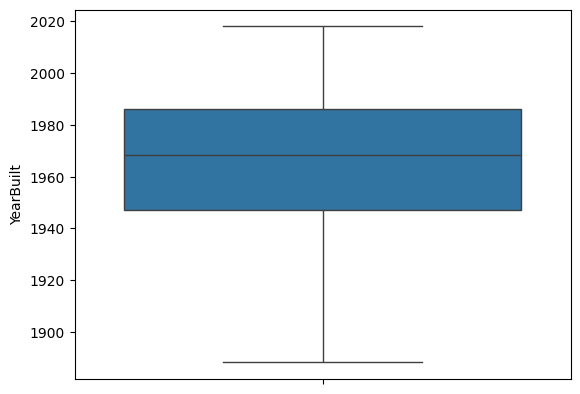

In [ ]:
sns.boxplot(merged2['YearBuilt'])

<Axes: xlabel='YearBuilt', ylabel='Count'>

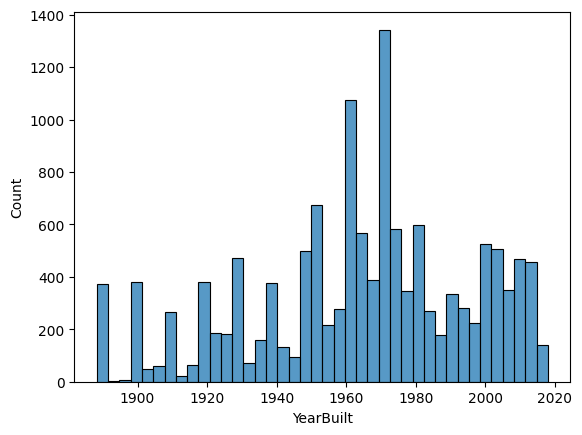

In [ ]:
sns.histplot(merged2['YearBuilt'])

In [ ]:
merged2.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,0
YearBuilt,0
PropertyID,0


In [ ]:
merged2["CouncilArea"].fillna("other",inplace=True)

/tmp/ipykernel_8159/445469702.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged2["CouncilArea"].fillna("other",inplace=True)


In [ ]:
merged2.isnull().sum()

,0
PropertyDetailsID,0
Type,0
Rooms,0
Bedroom2,0
Bathroom,0
Car,0
Landsize,0
BuildingArea,0
YearBuilt,0
PropertyID,0


In [ ]:
merged2.to_csv("cleaned1_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned1_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
merged2.shape

(13580, 24)